# Posture Detection V2 — 05 Session Engine and Smart Alerts

This notebook converts Notebook 04's frame analytics into a stateful session stream with confidence gating, sustained-bad-posture detection, alert cooldown, recovery handling, event history, and dashboard-ready exports.

It also fixes the semantic issue seen in Notebook 04: an issue is reported as `none` unless its severity reaches the configured threshold.

## 1. Load Notebook 04 analytics

In [10]:
import json
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

working_directory = Path.cwd()
if working_directory.name == 'notebooks': PROJECT_ROOT = working_directory.parent
elif working_directory.name == 'project_v2': PROJECT_ROOT = working_directory
else: PROJECT_ROOT = working_directory / 'project_v2'
SOURCE_DIR = PROJECT_ROOT / 'results' / 'posture_scoring_3d'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'session_engine'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TIMELINE_FILE = SOURCE_DIR / 'posture_timeline.csv'
if not TIMELINE_FILE.exists(): raise FileNotFoundError(f'Run Notebook 04 first: {TIMELINE_FILE}')
timeline = pd.read_csv(TIMELINE_FILE)
print('Frames:', len(timeline), '| videos:', timeline['video_filename'].nunique())
display(timeline.head())

Frames: 402 | videos: 1


,video_filename,frame,seconds,head_depth,head_lateral,neck_angle_deg,torso_lateral,torso_depth,shoulder_tilt,torso_length,...,forward_head_severity,slouching_severity,leaning_severity,shoulder_imbalance_severity,posture_score_raw,posture_score,bad_posture,bad_duration_seconds,smart_alert,dominant_issue
0,DEMO_PEXELS_9130469_side_view.mp4,0,0.000000,0.064881,0.400688,94.536310,-0.189485,-0.142016,-0.756128,2.003185,...,0.0,0.0,0.749907,0.0,85.001853,85.001853,False,0.0,False,leaning
1,DEMO_PEXELS_9130469_side_view.mp4,1,0.033333,0.064479,0.390060,95.174760,-0.198310,-0.141280,-0.754021,2.037550,...,0.0,0.0,0.676365,0.0,86.472700,85.737276,False,0.0,False,leaning
2,DEMO_PEXELS_9130469_side_view.mp4,2,0.066667,0.064160,0.382138,95.905594,-0.206182,-0.140460,-0.750670,2.068449,...,0.0,0.0,0.610770,0.0,87.784603,86.472700,False,0.0,False,leaning
3,DEMO_PEXELS_9130469_side_view.mp4,3,0.100000,0.063751,0.381210,96.171400,-0.211997,-0.140110,-0.752713,2.079371,...,0.0,0.0,0.562307,0.0,88.753853,87.128651,False,0.0,False,leaning
4,DEMO_PEXELS_9130469_side_view.mp4,4,0.133333,0.063487,0.380151,96.485400,-0.216700,-0.139831,-0.753813,2.088380,...,0.0,0.0,0.523115,0.0,89.537694,87.784603,False,0.0,False,leaning


## 2. Session policy

In [11]:
@dataclass(frozen=True)
class SessionPolicy:
    bad_score_threshold: float = 70.0
    issue_severity_threshold: float = 0.50
    alert_after_seconds: float = 5.0
    alert_cooldown_seconds: float = 30.0
    recovery_seconds: float = 2.0
    low_confidence_grace_seconds: float = 0.5

POLICY = SessionPolicy()
ISSUE_COLUMNS = {
    'forward_head': 'forward_head_severity',
    'slouching': 'slouching_severity',
    'leaning': 'leaning_severity',
    'shoulder_imbalance': 'shoulder_imbalance_severity',
}
display(pd.Series(asdict(POLICY), name='value').to_frame())

,value
bad_score_threshold,70.0
issue_severity_threshold,0.5
alert_after_seconds,5.0
alert_cooldown_seconds,30.0
recovery_seconds,2.0
low_confidence_grace_seconds,0.5


## 3. Stateful alert engine

States are `good`, `monitoring_bad`, `alert_active`, and `low_confidence`. Brief confidence gaps do not immediately erase a bad-posture streak.

In [12]:
class PostureSessionEngine:
    def __init__(self, fps, policy=POLICY):
        self.fps = float(fps); self.policy = policy
        self.bad_frames = 0; self.good_frames = 0; self.low_conf_frames = 0
        self.last_alert_seconds = -np.inf; self.previous_state = None

    def dominant_issue(self, row):
        values = {name: float(row[column]) for name, column in ISSUE_COLUMNS.items() if pd.notna(row[column])}
        if not values: return 'none', 0.0
        issue = max(values, key=values.get); value = values[issue]
        return (issue, value) if value >= self.policy.issue_severity_threshold else ('none', value)

    def step(self, row):
        seconds = float(row['seconds']); valid = bool(row['valid_pose']) and pd.notna(row['posture_score'])
        alert = False; issue, issue_severity = self.dominant_issue(row)
        if not valid:
            self.low_conf_frames += 1
            if self.low_conf_frames / self.fps > self.policy.low_confidence_grace_seconds:
                self.bad_frames = 0; self.good_frames = 0
            state = 'low_confidence'
        else:
            self.low_conf_frames = 0
            bad = float(row['posture_score']) < self.policy.bad_score_threshold
            if bad:
                self.bad_frames += 1; self.good_frames = 0
                bad_seconds = self.bad_frames / self.fps
                cooldown_ready = seconds - self.last_alert_seconds >= self.policy.alert_cooldown_seconds
                alert = bad_seconds >= self.policy.alert_after_seconds and cooldown_ready
                if alert: self.last_alert_seconds = seconds
                state = 'alert_active' if alert else 'monitoring_bad'
            else:
                self.good_frames += 1
                if self.good_frames / self.fps >= self.policy.recovery_seconds: self.bad_frames = 0
                state = 'good'
        bad_seconds = self.bad_frames / self.fps
        state_changed = state != self.previous_state; self.previous_state = state
        return {'engine_state': state, 'state_changed': state_changed, 'alert_emitted': alert, 'engine_bad_duration_seconds': bad_seconds, 'engine_issue': issue, 'engine_issue_severity': issue_severity}


## 4. Unit-test alert timing and cooldown

In [13]:
def synthetic_row(seconds, score=95.0, valid=True, severity=0.0):
    row = {'seconds': seconds, 'posture_score': score, 'valid_pose': valid}
    row.update({column: severity if name == 'slouching' else 0.0 for name, column in ISSUE_COLUMNS.items()})
    return pd.Series(row)

test_fps = 10; test_engine = PostureSessionEngine(test_fps)
test_output = []
for frame in range(120):
    test_output.append(test_engine.step(synthetic_row(frame / test_fps, score=40.0, severity=.8)))
alert_frames = [index for index, result in enumerate(test_output) if result['alert_emitted']]
assert alert_frames == [49], f'Expected one alert at 5 seconds, received {alert_frames}'
assert test_output[0]['engine_issue'] == 'slouching'
assert PostureSessionEngine(test_fps).step(synthetic_row(0, severity=.1))['engine_issue'] == 'none'
print('State-machine tests passed. First alert frame:', alert_frames[0])

State-machine tests passed. First alert frame: 49


## 5. Replay every session through the engine

In [14]:
processed_sessions = []; event_rows = []
for video, frame in timeline.groupby('video_filename', sort=True):
    frame = frame.sort_values('frame').reset_index(drop=True).copy()
    seconds_step = frame['seconds'].diff().dropna().median()
    fps = 1.0 / seconds_step if pd.notna(seconds_step) and seconds_step > 0 else 30.0
    engine = PostureSessionEngine(fps)
    engine_rows = [engine.step(row) for _, row in frame.iterrows()]
    engine_frame = pd.concat([frame, pd.DataFrame(engine_rows)], axis=1)
    processed_sessions.append(engine_frame)
    for _, row in engine_frame.loc[engine_frame['state_changed'] | engine_frame['alert_emitted']].iterrows():
        event_rows.append({'video_filename': video, 'frame': int(row['frame']), 'seconds': float(row['seconds']), 'event': 'alert' if row['alert_emitted'] else 'state_change', 'state': row['engine_state'], 'posture_score': None if pd.isna(row['posture_score']) else float(row['posture_score']), 'issue': row['engine_issue'], 'bad_duration_seconds': float(row['engine_bad_duration_seconds'])})
session_stream = pd.concat(processed_sessions, ignore_index=True)
event_history = pd.DataFrame(event_rows)
print('Stream rows:', len(session_stream), '| events:', len(event_history), '| alerts:', int(session_stream['alert_emitted'].sum()))
display(event_history.head(20))

Stream rows: 402 | events: 2 | alerts: 0


,video_filename,frame,seconds,event,state,posture_score,issue,bad_duration_seconds
0,DEMO_PEXELS_9130469_side_view.mp4,0,0.0,state_change,good,85.001853,leaning,0.0
1,DEMO_PEXELS_9130469_side_view.mp4,378,12.6,state_change,low_confidence,NaN,none,0.0


## 6. Dashboard summary and timeline

,video_filename,duration_seconds,valid_percent,mean_score,good_percent,monitoring_bad_seconds,alert_count,common_confirmed_issue
0,DEMO_PEXELS_9130469_side_view.mp4,13.366667,94.029851,98.464396,100.0,0.0,0,none


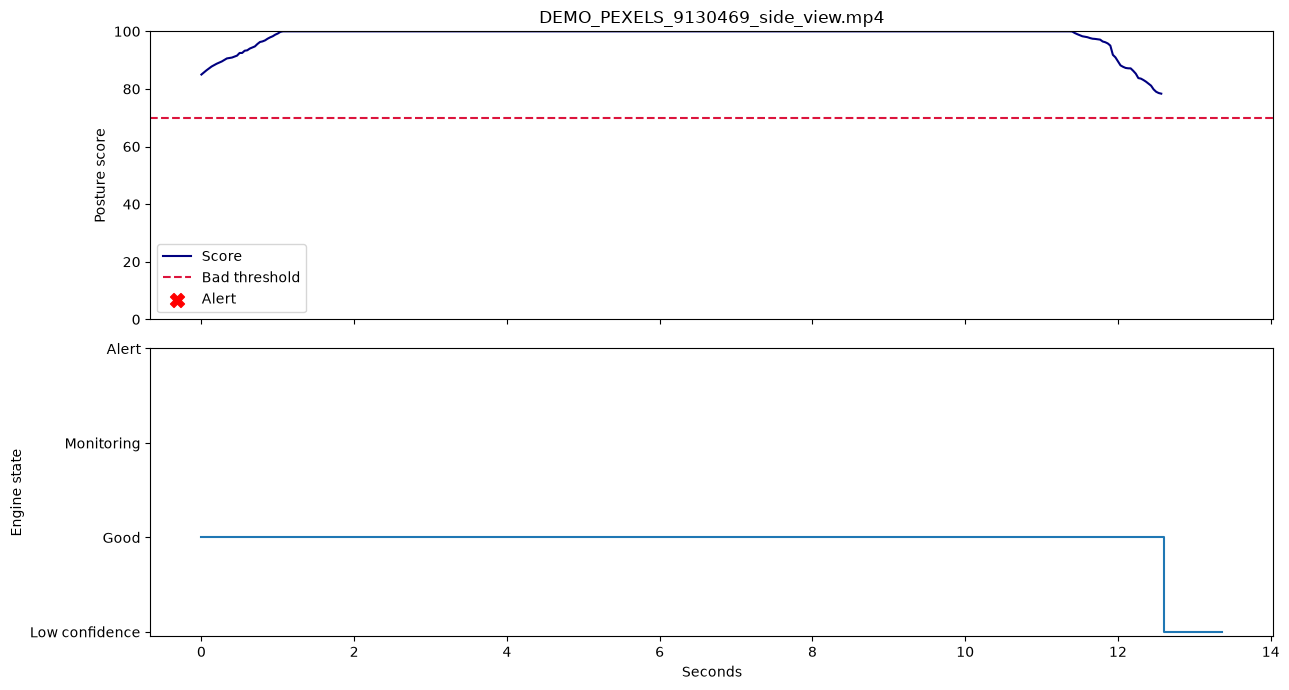

In [17]:
summary_rows = []
for video, frame in session_stream.groupby('video_filename'):
    valid = frame.loc[frame['engine_state'].ne('low_confidence')]
issue_counts = valid.loc[
    valid['engine_state'].isin(['monitoring_bad', 'alert_active'])
    & valid['engine_issue'].ne('none'),
    'engine_issue'
].value_counts()
summary_rows.append({'video_filename': video, 'duration_seconds': float(frame['seconds'].max()), 'valid_percent': float(len(valid) / len(frame) * 100), 'mean_score': float(valid['posture_score'].mean()), 'good_percent': float(valid['engine_state'].eq('good').mean() * 100), 'monitoring_bad_seconds': float(valid['engine_state'].isin(['monitoring_bad','alert_active']).sum() / (1 / frame['seconds'].diff().dropna().median())), 'alert_count': int(frame['alert_emitted'].sum()), 'common_confirmed_issue': issue_counts.index[0] if len(issue_counts) else 'none'})
dashboard_summary = pd.DataFrame(summary_rows)
display(dashboard_summary)
for video, frame in session_stream.groupby('video_filename'):
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    axes[0].plot(frame['seconds'], frame['posture_score'], color='navy', label='Score')
    axes[0].axhline(POLICY.bad_score_threshold, color='crimson', linestyle='--', label='Bad threshold')
    alerts = frame.loc[frame['alert_emitted']]
    axes[0].scatter(alerts['seconds'], alerts['posture_score'], color='red', marker='X', s=100, label='Alert')
    axes[0].set_ylim(0,100); axes[0].set_ylabel('Posture score'); axes[0].legend(); axes[0].set_title(video)
    state_codes = frame['engine_state'].map({'low_confidence':0,'good':1,'monitoring_bad':2,'alert_active':3})
    axes[1].step(frame['seconds'], state_codes, where='post'); axes[1].set_yticks([0,1,2,3], ['Low confidence','Good','Monitoring','Alert'])
    axes[1].set_xlabel('Seconds'); axes[1].set_ylabel('Engine state'); plt.tight_layout(); plt.show()

## 7. Export dashboard-ready history

In [18]:
STREAM_FILE = OUTPUT_DIR / 'session_stream.csv'
EVENT_FILE = OUTPUT_DIR / 'event_history.csv'
SUMMARY_FILE = OUTPUT_DIR / 'dashboard_summary.csv'
JSONL_FILE = OUTPUT_DIR / 'dashboard_stream.jsonl'
CONFIG_FILE = OUTPUT_DIR / 'session_engine_config.json'
session_stream.to_csv(STREAM_FILE, index=False); event_history.to_csv(EVENT_FILE, index=False); dashboard_summary.to_csv(SUMMARY_FILE, index=False)
with JSONL_FILE.open('w', encoding='utf-8') as file:
    for record in session_stream[['video_filename','frame','seconds','posture_score','engine_state','engine_issue','engine_issue_severity','alert_emitted']].to_dict('records'):
        clean = {key: (None if pd.isna(value) else value.item() if isinstance(value, np.generic) else value) for key, value in record.items()}
        file.write(json.dumps(clean) + '\n')
with CONFIG_FILE.open('w') as file:
    json.dump({'created_utc': datetime.now(timezone.utc).isoformat(), 'policy': asdict(POLICY), 'states': ['low_confidence','good','monitoring_bad','alert_active'], 'note': 'Public demo outputs are pipeline validation only.'}, file, indent=2)
for path in (STREAM_FILE, EVENT_FILE, SUMMARY_FILE, JSONL_FILE, CONFIG_FILE): print('Saved:', path.resolve())

Saved: C:\Users\manth\Desktop\project_v2\results\session_engine\session_stream.csv
Saved: C:\Users\manth\Desktop\project_v2\results\session_engine\event_history.csv
Saved: C:\Users\manth\Desktop\project_v2\results\session_engine\dashboard_summary.csv
Saved: C:\Users\manth\Desktop\project_v2\results\session_engine\dashboard_stream.jsonl
Saved: C:\Users\manth\Desktop\project_v2\results\session_engine\session_engine_config.json


## V2 prototype checkpoint

The prototype now covers temporal 2D extraction, MotionBERT 3D lifting, confidence filtering, calibration-relative posture scoring, issue identification, smoothing, duration tracking, smart alerts, session history, and dashboard exports.

The next scientifically necessary phase is **participant data collection and annotation**, followed by participant-independent evaluation against the V1 2D + Random Forest baseline. Do not claim classification accuracy from the public demo clip.